<a href="https://colab.research.google.com/github/dariojuri/Progetto_ML/blob/main/Progetto_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Caricamento del DataBase

In [14]:
!pip install -q ucimlrepo #Installa una libreria che su Colab non c'è
# !-> comando di sistema, -q lo nasconde dal log
import pandas as pd, numpy as np #pandas per le tabelle, numpy per i calcoli numerici
import matplotlib.pyplot as plt, seaborn as sns #librerie per i grafici
from ucimlrepo import fetch_ucirepo #una sola libreria per scaricare il dataset

ds = fetch_ucirepo(id=296)       #scarica il dataset n. 296 di UCI (Diabetes 130)
#ds paccehtto completo con dati e metadati
df = ds.data.original.copy()     #prende la tabella completa, tutte le 50 colonne
df = df.replace('?', np.nan)     #trasforma i '?' in veri valori mancanti
#df varibili che contiene dataset sotto forma di DataFrame

print(df.shape)
df.head()

/usr/local/lib/python3.13/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


Struttura del database: nome colonna, numero di missing e tipo della colonna.

In [9]:
df.info()
print(df.nunique().sort_values(ascending=False).head(15))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

Analizza il target e conta le occorrenze.

readmitted
NO     0.539
>30    0.349
<30    0.112
Name: proportion, dtype: float64
Positivi: 0.112


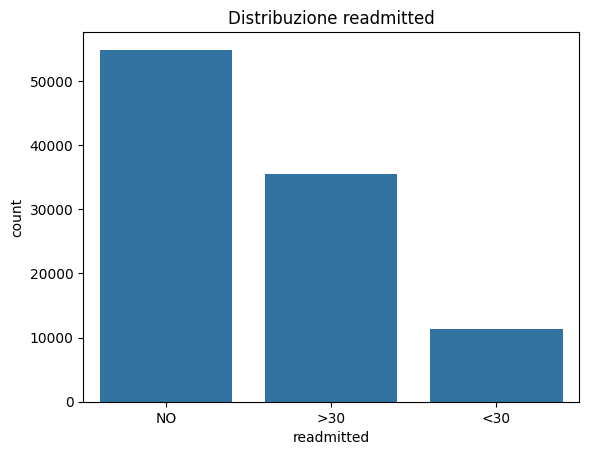

In [10]:
print(df['readmitted'].value_counts(normalize=True).round(3))
df['target'] = (df['readmitted'] == '<30').astype(int)
print('Positivi:', round(df['target'].mean(), 3))
sns.countplot(x='readmitted', data=df); plt.title('Distribuzione readmitted'); plt.show()

Conteggio dei valori mancanti

weight               96.9
max_glu_serum        94.7
A1Cresult            83.3
medical_specialty    49.1
payer_code           39.6
race                  2.2
diag_3                1.4
diag_2                0.4
diag_1                0.0
dtype: float64


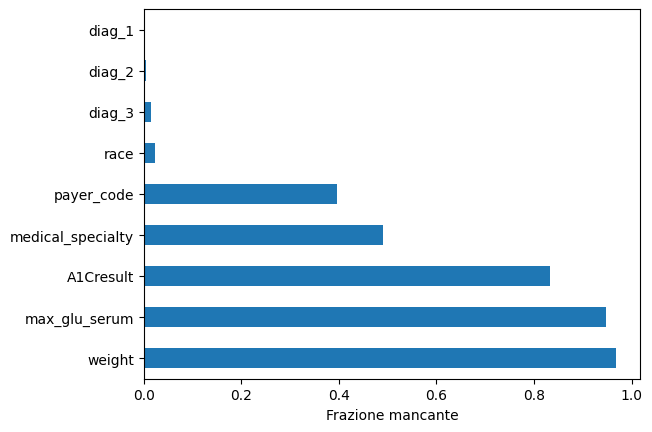

In [11]:
miss = df.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
print((miss * 100).round(1))
miss.plot.barh(); plt.xlabel('Frazione mancante'); plt.show()

Conteggio dei pazienti unici, da singolarizzare nel dataset

In [12]:
print('Ricoveri:', len(df), '| Pazienti unici:', df['patient_nbr'].nunique())
print(df['discharge_disposition_id'].value_counts().head(10))

Ricoveri: 101766 | Pazienti unici: 71518
discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
Name: count, dtype: int64


Dataset Originale con valori mancanti

In [13]:
from google.colab import data_table
data_table.enable_dataframe_formatter()
pd.set_option('display.max_columns', None)
df.sample(25)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,target
97100,384329102,106356708,Caucasian,Female,[30-40),NaN,1,1,7,2,HM,NaN,3,0,11,0,1,3,276,276,786,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,>30,0
41137,127453566,41904171,Caucasian,Male,[50-60),NaN,1,22,7,14,MD,NaN,55,6,60,0,0,0,414,413,250.01,9,NaN,NaN,Steady,No,No,No,No,No,Down,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,<30,1
45117,139336170,100860030,Caucasian,Male,[80-90),NaN,3,1,7,2,MC,Emergency/Trauma,1,0,9,0,0,0,250.8,496,272,6,NaN,NaN,Steady,No,No,No,No,No,No,Steady,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,>30,0
1248,8856594,79469091,Other,Female,[70-80),NaN,1,3,7,11,NaN,Family/GeneralPractice,47,0,9,0,0,0,38,112,437,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO,0
81128,250981908,43459803,Caucasian,Male,[70-80),NaN,1,6,7,6,MC,NaN,54,2,12,0,0,1,185,596,NaN,8,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,0
89870,291198294,51689619,Caucasian,Male,[70-80),NaN,1,1,7,4,MC,Emergency/Trauma,55,0,22,0,0,0,38,276,250.4,9,NaN,NaN,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,0
70183,200842428,85077441,Caucasian,Male,[30-40),NaN,1,6,7,3,HM,NaN,60,3,11,2,1,1,250.8,707,682,9,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,>30,0
15263,58778202,3888972,Caucasian,Female,[50-60),NaN,1,18,7,2,NaN,NaN,40,3,15,0,0,0,414,411,250,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0
521,4361868,3489048,Caucasian,Male,[60-70),NaN,6,25,7,9,NaN,Family/GeneralPractice,56,5,24,0,0,0,557,70,496,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO,0
94718,351886064,73590318,Caucasian,Male,[70-80),[125-150),1,3,7,8,MC,InternalMedicine,70,0,17,3,0,1,431,348,276,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30,0
